# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [37]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [38]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: <StringArray>
[ 'United States',          'China',          'India',        'Germany',
 'United Kingdom',         'France',         'Brazil',          'Japan',
         'Canada',      'Australia',    'South Korea',         'Russia',
   'South Africa',         'Mexico',      'Indonesia']
Length: 15, dtype: str

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


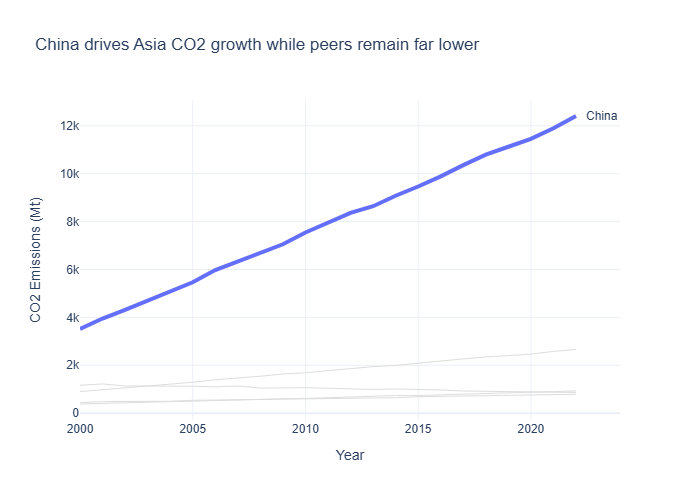

In [39]:
# Task 1 — Multi-series line with highlight
asia = df[df['Region']=='Asia'].copy()
highlight = 'China' if 'China' in asia['Country'].unique() else asia['Country'].iloc[0]

fig = go.Figure()

for country in asia['Country'].unique():
    d = asia[asia['Country']==country].sort_values('Year')
    if country == highlight:
        fig.add_trace(go.Scatter(
            x=d['Year'], y=d['CO2_Mt'],
            mode='lines',
            line=dict(width=4),
            name=country
        ))
        fig.add_annotation(
            x=d['Year'].max(), y=d['CO2_Mt'].iloc[-1],
            text=country, showarrow=False, xanchor='left', xshift=8
        )
    else:
        fig.add_trace(go.Scatter(
            x=d['Year'], y=d['CO2_Mt'],
            mode='lines',
            line=dict(color='#DDDDDD', width=1),
            hoverinfo='skip',
            showlegend=False
        ))

fig.update_layout(
    title=f'{highlight} drives Asia CO2 growth while peers remain far lower',
    template='plotly_white',
    font=dict(family='Arial'),
    xaxis_title='Year',
    yaxis_title='CO2 Emissions (Mt)',
    showlegend=False
)
fig.show()
fig.show(renderer="png")

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


In [ ]:
reg = df[df['Year'].isin([2000, 2022])].groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()

wide = reg.pivot(index='Region', columns='Year', values='CO2_Mt').dropna().reset_index()
wide.columns = ['Region', 'y2000', 'y2022']
wide['change'] = wide['y2022'] - wide['y2000']

fig = go.Figure()

offsets = {
    'Asia': 0,
    'North America': 0,
    'Europe': 20,
    'Latin America': 45,
    'Africa': -20,
    'Oceania': -45
}

for _, r in wide.iterrows():
    color = 'crimson' if r['change'] > 0 else 'seagreen'

    fig.add_trace(go.Scatter(
        x=[0, 1],
        y=[r['y2000'], r['y2022']],
        mode='lines+markers',
        line=dict(color=color, width=3),
        marker=dict(size=8),
        showlegend=False
    ))

    off = offsets.get(r['Region'], 0)

    fig.add_annotation(
        x=0, y=r['y2000'] + off,
        text=f"{r['Region']} {r['y2000']:.0f}",
        showarrow=False,
        xanchor='right'
    )

    fig.add_annotation(
        x=1, y=r['y2022'] + off,
        text=f"{r['Region']} {r['y2022']:.0f}",
        showarrow=False,
        xanchor='left'
    )

fig.update_layout(
    template='plotly_white',
    title='Asia saw the largest rise in average regional CO2 emissions',
    xaxis=dict(
        tickvals=[0,1],
        ticktext=['2000','2022'],
        title='Year'
    ),
    yaxis=dict(
        title='Average CO2 (Mt)',
        showgrid=False
    ),
    height=750,
    width=1200
)

fig.show()